### DATA Directory

In [1]:
#Change to match your personal directory on the super-computer
DATA_FILE_PATH=r'C:\Users\Porter\Desktop\SEC Filings\edgar_benchmark'

CRSP_MONTHLY_W_TICKER_PATH=r'C:\Users\Porter\Desktop\SEC Filings\Lazy Prices\crsp_1990-2024_monthly.csv'

FF5_MONTHLY=r"C:\Users\Porter\Desktop\SEC Filings\Lazy Prices\ff5.csv"


### Replication

#### Import packages

In [2]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
# import sf_quant.data as sfd
# import sf_quant.optimizer as sfo
# import sf_quant.backtester as sfb
# import sf_quant.performance as sfp
import datetime as dt
import numpy as np

#for cos similarity
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, manhattan_distances, rbf_kernel,polynomial_kernel

#progress bar
from tqdm import tqdm

#kl div
from scipy.special import rel_entr  # for KL

#js
from scipy.spatial.distance import jensenshannon

#hellinger
from scipy.spatial.distance import euclidean




#### Importing Data

In [3]:
SCHEMA_10K_data = {
    # identifiers
    "cik": pl.Int64,# keep as string (leading zeros)
    "cusip": pl.Utf8, # string

    # dates
    "filing_date": pl.Date,

    # 10-K items (always text)
    "Item 1": pl.Utf8,
    "Item 1A": pl.Utf8,
    "Item 1B": pl.Utf8,
    "Item 1C": pl.Utf8,
    "Item 2": pl.Utf8,
    "Item 3": pl.Utf8,
    "Item 4": pl.Utf8,
    "Item 5": pl.Utf8,
    "Item 6": pl.Utf8,
    "Item 7": pl.Utf8,
    "Item 7A": pl.Utf8,
    "Item 8": pl.Utf8,
    "Item 9": pl.Utf8,
    "Item 9A": pl.Utf8,
    "Item 9B": pl.Utf8,
    "Item 10": pl.Utf8,
    "Item 11": pl.Utf8,
    "Item 12": pl.Utf8,
    "Item 13": pl.Utf8,
    "Item 14": pl.Utf8,
    "Item 15": pl.Utf8,
    'year': pl.Int64,
}

SCHEMA_10K_read = {
    # identifiers
    "cik": pl.Int64,# keep as string (leading zeros)
    "cusip": pl.Utf8, # string

    # dates
    "filing_date": pl.Utf8,

    # 10-K items (always text)
    "Item 1": pl.Utf8,
    "Item 1A": pl.Utf8,
    "Item 1B": pl.Utf8,
    "Item 1C": pl.Utf8,
    "Item 2": pl.Utf8,
    "Item 3": pl.Utf8,
    "Item 4": pl.Utf8,
    "Item 5": pl.Utf8,
    "Item 6": pl.Utf8,
    "Item 7": pl.Utf8,
    "Item 7A": pl.Utf8,
    "Item 8": pl.Utf8,
    "Item 9": pl.Utf8,
    "Item 9A": pl.Utf8,
    "Item 9B": pl.Utf8,
    "Item 10": pl.Utf8,
    "Item 11": pl.Utf8,
    "Item 12": pl.Utf8,
    "Item 13": pl.Utf8,
    "Item 14": pl.Utf8,
    "Item 15": pl.Utf8,
}


In [4]:
#init an empty df
data=pl.DataFrame(schema=SCHEMA_10K_data)

for i in tqdm(range(4,25)):
    year=2000+i
    sub=pl.read_parquet(rf'{DATA_FILE_PATH}\{str(year)}_10k_items.parquet',schema=SCHEMA_10K_read)

    #make filing date a pl.date
    sub=sub.with_columns(pl.col('filing_date').cast(pl.Date))

    #make a year col for ez comparision
    sub=sub.with_columns((pl.col('filing_date').dt.year()).alias('year'))
    
    sub=sub.filter(pl.col('year')==year)
    
    data=pl.concat([data,sub],how='vertical_relaxed')


100%|██████████| 21/21 [01:46<00:00,  5.09s/it]


In [5]:
#clean data

#drop null tickers
data=data.filter(pl.col('cusip').is_not_null())

#make cusip length8
data = data.with_columns(
    pl.col("cusip").str.slice(0, 8).alias("cusip8"))

#drop where filing date is null
data=data.filter(pl.col('filing_date').is_not_null())

#make a date column where it is the last day of the month so that we can merge it to the date from CRSP monthly
data=data.with_columns((pl.col('filing_date').dt.month_end()).alias('date'))


#sort ticker ascending and year descending to make operations easier down the line
data = data.sort(
    ["cik", "year"],
    descending=[False, True]
)



#### Similarity Calculation

- Cosine (Equal and TF-IDF weightings)
- Min Edit
- Jaccard
- Simple
- ML/LLM similarity metrics

In [6]:
# vectorizer = CountVectorizer(
#     lowercase=True,
#     token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'
# )



vectorizer=TfidfVectorizer(lowercase=True,token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')





In [7]:
cols_to_remove = {'cusip', 'filing_date', 'year', 'date','cik'}
itemlist = [c for c in data.columns if c not in cols_to_remove]
print(itemlist)


['Item 1', 'Item 1A', 'Item 1B', 'Item 1C', 'Item 2', 'Item 3', 'Item 4', 'Item 5', 'Item 6', 'Item 7', 'Item 7A', 'Item 8', 'Item 9', 'Item 9A', 'Item 9B', 'Item 10', 'Item 11', 'Item 12', 'Item 13', 'Item 14', 'Item 15', 'cusip8']


In [8]:
ITEM='Item 1A'

Vector Similarities

In [9]:
#there is most definitely a faster way to do this, but I am not a CS major so this works for me haha

cik_list=data['cik'].unique().to_list() 
cik_list.sort() #sort it so we match how our data df is

# cik_list = cik_list[:3] #first three for testign
sim_list_kl=[]
sim_list_js=[]
distance_hellinger=[]


for cik in tqdm(cik_list): #this method assumes that my data is sorted on cik and year where cik is increasing and year is decreasing (within cik)
    sub=data.filter(pl.col('cik')==cik) #filter to cik
    year_item=sub.select([ITEM,'year']) #filter to item
    year_list=year_item['year'].to_list() #get a list of the years so we can iterate on it too


    sim_list_kl_cik=[]
    sim_list_js_cik=[]
    distance_hellinger_cik=[]


    for year in year_list:
        try:
            doc1 = year_item.filter(pl.col('year') == year).select(ITEM).item() #get this year
            doc2 = year_item.filter(pl.col('year') == (year - 1)).select(ITEM).item() #last years item

        except ValueError:
            sim_list_kl_cik.append(None) #when compariing our earliest year to the year before it throws an error, so we append a none (null) value
            distance_hellinger_cik.append(None)
            sim_list_js_cik.append(None)
            continue

        doc_list=[doc1,doc2]
        try:
            X = vectorizer.fit_transform(doc_list) #vectorize it (uncomment this if using tfidf and count) 

            counts = X.toarray()

            # Add small smoothing to avoid log(0)
            epsilon = 1e-10
            counts = counts + epsilon

            # Convert to probability distributions
            P = counts[0] / counts[0].sum()
            Q = counts[1] / counts[1].sum()

            # Compute KL divergence
            kl = np.sum(rel_entr(P, Q))  # D_KL(P || Q) #this is bounded below by 0, max is pos infinity

            #jensen shannon
            js = jensenshannon(P, Q)**2 #check bounds

            hellinger = euclidean(np.sqrt(P), np.sqrt(Q)) / np.sqrt(2) #check bounds


        except AttributeError:
            sim_list_kl_cik.append(None)
            sim_list_js_cik.append(None)
            distance_hellinger_cik.append(None)
             #if a cik is missing item this will get thrown because we will not be able to do cos similarity_pearson with a null
            continue


        sim_list_kl_cik.append(kl)
        distance_hellinger_cik.append(hellinger)
        sim_list_js_cik.append(js)


        
    sim_list_kl.extend(sim_list_kl_cik) #add all the similarities for the cik to the overall list
    distance_hellinger.extend(distance_hellinger_cik)
    sim_list_js.extend(sim_list_js_cik)
    

100%|██████████| 6285/6285 [14:22<00:00,  7.29it/s] 


In [10]:
#add vec metrics
data = data.with_columns([
    pl.Series(f'{ITEM}_kl', sim_list_kl),
    pl.Series(f'{ITEM}_js', sim_list_js),
    pl.Series(f'{ITEM}_hellinger', distance_hellinger),
   
])

In [11]:
data

cik,cusip,filing_date,Item 1,Item 1A,Item 1B,Item 1C,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 7A,Item 8,Item 9,Item 9A,Item 9B,Item 10,Item 11,Item 12,Item 13,Item 14,Item 15,year,cusip8,date,Item 1A_kl,Item 1A_js,Item 1A_hellinger
i64,str,date,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,date,f64,f64,f64
20,"""482730108""",2009-03-13,"""Item 1. Business. General …","""Item 1A. Risk …","""Item 1B. Unresolved …",null,"""Item 2. Properties. We ow…","""Item 3. Legal …","""Item 4. Submission …","""Item 5. Market …","""Item 6. Selected …","""Item 7. Managements …","""Item 7A. Quantitative …","""Item 8. Financial …","""Item 9. Change …","""Item 9A. Controls …","""Item 9B. Other …","""Item 10. Directors, …","""Item 11. Executive …","""Item 12. Security …","""Item 13. Certain …","""Item 14. Principal …","""Item 15. Exhibits …",2009,"""48273010""",2009-03-31,0.900447,0.02489,0.183801
20,"""482730108""",2008-03-12,"""Item 1. Business. General …","""Item 1A. Risk …","""Item 1B. Unresolved …",null,"""Item 2. Properties. We ow…","""Item 3. Legal …","""Item 4. Submission …","""Item 5. Market …","""Item 6. Selected …","""Item 7. Managements …","""Item 7A. Quantitative …","""Item 8. Financial …","""Item 9. Change …","""Item 9A. Controls …","""Item 9B. Other …","""Item 10. Directors, …","""Item 11. Executive …","""Item 12. Security …","""Item 13. Certain …","""Item 14. Principal …","""Item 15. Exhibits …",2008,"""48273010""",2008-03-31,1.300747,0.030579,0.20614
20,"""482730108""",2007-03-09,"""Item 1. Business.General …","""Item 1A. Risk Factors. Ou…","""Item 1B. Unresolved Staff Comm…",null,"""Item 2. Properties. We ow…","""Item 3. Legal Proceedings. …","""Item 4. Submission of Matters …","""Item 5. Market for Registrant…","""Item 6. Selected Financial Dat…","""Item 7. Managements Discussio…","""Item 7A. Quantitative and Qual…","""Item 8. Financial Statements a…","""Item 9. Change In and Disagree…","""Item 9A. Controls and Procedur…","""Item 9B. Other Information. …","""Item 10. Directors, Executive …","""Item 11. Executive Compensatio…","""Item 12. Security Ownership of…","""Item 13. Certain Relationships…","""Item 14. Principal Accountant …","""Item 15. Exhibits and Financia…",2007,"""48273010""",2007-03-31,1.458536,0.036287,0.224532
20,"""482730108""",2006-03-23,"""Item 1. Business.General …","""Item 1A. Risk Factors. Risks A…","""Item 1B. Unresolved Staff Comm…",null,"""Item 2. Properties. We ow…","""Item 3. Legal Proceedings. …",null,"""Item 5. Market for Registran…",null,"""Item 7. Managements Discussio…","""Item 7A. Quantitative and Qual…","""Item 8. Financial Statements a…",null,null,null,"""Item 10. Directors and Executi…","""Item 11. Executive Compensatio…",null,null,"""Item 14. Principal Accountant …",null,2006,"""48273010""",2006-03-31,null,null,null
20,"""482730108""",2005-03-31,"""Item 1. Business.General …",null,null,null,"""Item 2. Properties. We ow…","""Item 3. Legal Proceedings. …","""Item 4. Submission of Matters …","""Item 5. Market for Registrant…","""Item 6. Selected Financial Dat…","""Item 7. Managements Discuss…","""Item 7A. Quantitative and Qual…","""Item 8. Financial Statements a…","""Item 9. Change In and Disagr…","""Item 9A. Controls and Procedur…","""Item 9B. Other Information. …","""Item 10. Directors and Executi…","""Item 11. Executive Compensatio…","""Item 12. Security Ownership …","""Item 13. Certain Relationship…","""Item 14. Principal Accountant …","""Item 15. Exhibits, Financial S…",2005,"""48273010""",2005-03-31,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1981792,"""44267T102""",2024-02-27,"""Item 1. Business OVERVIEW …","""Item 1A. Risk Factors The risk…","""Item 1B. Unresolved Staff Com…","""Item 1C. Cybersecurity Risk M…","""Item 2. Properties Our corpor…","""Item 3. Legal Proceedings We,…","""Item 4. Mine Safety Disclosur…","""Item 5. Market for Registrant…","""Item 6. [Reserved] HHH 2023 F…","""Item 7. Managemen

#### Portfolio Construction

Load CRSP (pricing data)

In [12]:
#load CRSP data and clean it
crsp = pl.read_csv(
    CRSP_MONTHLY_W_TICKER_PATH,
    schema_overrides={"NCUSIP": pl.Utf8,"CUSIP":pl.Utf8,"RET":pl.Utf8,"RETX":pl.Utf8} #do this so we can load it in and then clean these cols
)

#chat said to use ncusip instead
crsp = crsp.with_columns(
    pl.col("CUSIP").str.slice(0, 8).alias("cusip8")
)

crsp=crsp.with_columns(pl.col('RET').cast(pl.Float32,strict=False)) #make RET a float
# crsp=crsp.with_columns(pl.col('RETX').cast(pl.Float32,strict=False))

#make date a pl.Date
crsp=crsp.with_columns(pl.col('date').cast(pl.Date))
#filter to 10 and 11 sharecode bc that is standard practice
crsp=crsp.filter((pl.col('SHRCD')==10) |(pl.col('SHRCD')==11))

#rename all the cols to lowercase for consistency
crsp = crsp.rename({c: c.lower() for c in crsp.columns})
#get rid of negative price
crsp=crsp.with_columns((pl.col('prc').abs()).alias('prc'))
crsp


permno,date,shrcd,exchcd,ticker,cusip,prc,vol,ret,cusip8
i64,date,i64,i64,str,str,f64,i64,f32,str
10001,1990-01-31,11,3,"""GFGC""","""36720410""",9.9375,353,-0.018519,"""36720410"""
10001,1990-02-28,11,3,"""GFGC""","""36720410""",9.875,149,-0.006289,"""36720410"""
10001,1990-03-30,11,3,"""GFGC""","""36720410""",9.875,127,0.012658,"""36720410"""
10001,1990-04-30,11,3,"""GFGC""","""36720410""",9.875,166,0.0,"""36720410"""
10001,1990-05-31,11,3,"""GFGC""","""36720410""",9.75,279,-0.012658,"""36720410"""
…,…,…,…,…,…,…,…,…,…
93436,2024-08-30,11,3,"""TSLA""","""88160R10""",214.11,16108365,-0.07739,"""88160R10"""
93436,2024-09-30,11,3,"""TSLA""","""88160R10""",261.63,16042065,0.221942,"""88160R10"""
93436,2024-10-31,11,3,"""TSLA""","""88160R10""",249.85001,19014312,-0.045025,"""88160R10"""


In [13]:
#merge CRSP and SEC data
merged=data.join(crsp, on=['date','cusip8'],how='right')

Make Quintiles

In [14]:
################################################################
#SHIFT SIGNALS
################################################################

#sort the data
merged=merged.sort(['permno','date'])

#shift signal to avoid lookahead
metrics = ["kl", "js", "hellinger"]

merged = merged.with_columns([
    pl.col(f"{ITEM}_{m}").shift(1).over("permno").alias(f"{ITEM}_{m}")
    for m in metrics
])

###################################################################
#MAKE BINS
###################################################################

#bin similarity
labels = [str(i) for i in range(5)]

#bin all the metrics
merged = merged.with_columns([
    pl.col(f"{ITEM}_{m}")
      .qcut(5, labels=labels, allow_duplicates=True)
      .over("date")
      .alias(f"{ITEM}_{m}_bin")
    for m in metrics
    if f"{ITEM}_{m}" in merged.columns
])

#####################################################################
#HOLDING
#####################################################################

# sort first
merged = merged.sort(["permno", "date"])

# find all bin columns automatically
bin_cols = [col for col in merged.columns if col.endswith("_bin")]

merged = merged.with_columns([
    pl.col(col)
      .fill_null(strategy="forward", limit=11)
      .over("permno")
      .alias(col)
    for col in bin_cols
])

In [15]:
#make port dicts for each similarity calculation

#this is the raw returns of each of them
ports_sim_dict={}

#make the equal weight ports for each sim metric
for sim_metric in metrics:
    ports_sim_dict[sim_metric]=merged.group_by(['date',f"{ITEM}_{sim_metric}_bin"]).agg(pl.col('ret').mean())
    ports_sim_dict[sim_metric]=ports_sim_dict[sim_metric].filter(pl.col(f"{ITEM}_{sim_metric}_bin").is_not_null())
    ports_sim_dict[sim_metric]=ports_sim_dict[sim_metric].sort('date',f"{ITEM}_{sim_metric}_bin")
    ports_sim_dict[sim_metric]=ports_sim_dict[sim_metric].pivot(f"{ITEM}_{sim_metric}_bin",index='date',values='ret')
    ports_sim_dict[sim_metric]=ports_sim_dict[sim_metric].with_columns((pl.col('0') -pl.col('4')).alias('spread')) #all the distribution based ones have ones that are lower numbers mean more similiar

sharpes=[]
#caluclate sharpe ratios for each metric
for sim_metric in metrics:
    avg_ret=ports_sim_dict[sim_metric]['spread'].mean() #get the sharpes for each of the spreads
    ret_std=ports_sim_dict[sim_metric]['spread'].std()

    #calcuate sharpe and append to the list
    sharpe=avg_ret/ret_std *np.sqrt(12) #annualize it
    sharpes.append(sharpe)

#make a sharpe df
sharpe_df = pl.DataFrame({
    "metric": metrics,
    "sharpe": sharpes
})


In [16]:
sharpe_df.to_pandas().round(3)

,metric,sharpe
0,kl,0.584
1,js,0.516
2,hellinger,0.520


In [17]:
#make vol scaled of each port in each port
labels_w_spread=labels+['spread']

for sim_metric in metrics:
    #loop over all the bins in the the data frame
    for bin in labels_w_spread:
        try:
            ports_sim_dict[sim_metric]=ports_sim_dict[sim_metric].with_columns(
                (pl.col(bin)/(pl.col(bin).rolling_std(window_size=12).shift(1)*np.sqrt(12))).alias(f'{bin}_vs')
            )
        except Exception:
            continue

#now do cumulative sum
for sim_metric in metrics:
    #loop over all the bins in the the data frame
    for bin in labels_w_spread:
        try:
            ports_sim_dict[sim_metric]=ports_sim_dict[sim_metric].with_columns(
                (pl.col(f'{bin}_vs').cum_sum()).alias(f'{bin}_vs_cum')
                )
        except Exception: #this is because sometimes we will not have all the bins (this happens when we have the same cutoffs)
            continue

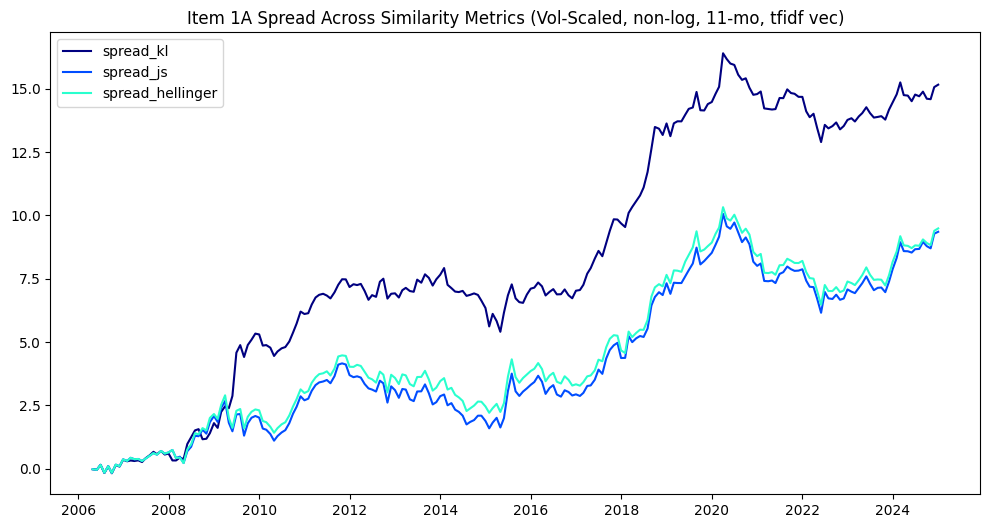

In [18]:
plt.figure(figsize=(12,6))

#color mapping code courtesy of chat
n = 6
cmap = plt.cm.jet  # or plasma, turbo, etc.
colors = cmap(np.linspace(0, 1, n))

#visualize it
for sim_metric in metrics:
    c=metrics.index(sim_metric)#set the color var
    
    port_pd=ports_sim_dict[sim_metric].to_pandas() #change to pandas so we can plot with mpl
    x=port_pd['date'] #it should be the same across all the t (roughly the same)

    #loop thru the bins and plot each of the cum rets
    y=port_pd[f'spread_vs_cum']
    plt.plot(x,y,label=f'spread_{sim_metric}',color=colors[c])

plt.legend()
plt.title(f'{ITEM} Spread Across Similarity Metrics (Vol-Scaled, non-log, 11-mo, tfidf vec)')
plt.show()
